# Phase 4: SQL-Driven Dashboard

No BI tool here on purpose — every chart below runs the actual `.sql` file from `sql/` against
`netflix.db` via `run_sql()`, then renders the result with matplotlib. Nothing is recomputed in
pandas; the query *is* the data source, and the chart is just its rendering. Charts are grouped
the same way the original 3-page dashboard plan was: Overview, Ratings, People.

Individual PNGs land in `dashboard/`; the last cell assembles six headline panels into
`dashboard/dashboard.png`, the single image linked from the README.

Country panels label with full country names (`COUNTRY_NAMES` in the setup cell), not raw ISO codes — a reader shouldn't need a legend key to decode `KR` as South Korea.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path("..") / "netflix.db"
SQL_DIR = Path("..") / "sql"
OUT_DIR = Path("..") / "dashboard"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Validated categorical palette (fixed hue order — see dataviz skill), light-mode chart chrome.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
)
INK = "#0b0b0b"
INK_SOFT = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.size": 10.5,
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def run_sql(filename: str) -> pd.DataFrame:
    """Run an actual .sql file from sql/ against netflix.db. Every chart in this
    notebook traces back to the exact query file it visualizes."""
    query = (SQL_DIR / filename).read_text()
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql(query, conn)


def style_axes(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    if grid_axis == "y":
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    elif grid_axis == "x":
        ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(length=0)


COUNTRY_NAMES = {
    "AE": "United Arab Emirates", "AF": "Afghanistan", "AL": "Albania", "AO": "Angola",
    "AR": "Argentina", "AT": "Austria", "AU": "Australia", "BD": "Bangladesh",
    "BE": "Belgium", "BF": "Burkina Faso", "BG": "Bulgaria", "BR": "Brazil",
    "BS": "Bahamas", "BT": "Bhutan", "BY": "Belarus", "CA": "Canada",
    "CD": "DR Congo", "CH": "Switzerland", "CL": "Chile", "CM": "Cameroon",
    "CN": "China", "CO": "Colombia", "CU": "Cuba", "CY": "Cyprus",
    "CZ": "Czech Republic", "DE": "Germany", "DK": "Denmark", "DZ": "Algeria",
    "EG": "Egypt", "ES": "Spain", "FI": "Finland", "FO": "Faroe Islands",
    "FR": "France", "GB": "United Kingdom", "GE": "Georgia", "GH": "Ghana",
    "GL": "Greenland", "GR": "Greece", "GT": "Guatemala", "HK": "Hong Kong",
    "HR": "Croatia", "HU": "Hungary", "ID": "Indonesia", "IE": "Ireland",
    "IL": "Israel", "IN": "India", "IO": "British Indian Ocean Territory",
    "IQ": "Iraq", "IR": "Iran", "IS": "Iceland", "IT": "Italy", "JO": "Jordan",
    "JP": "Japan", "KE": "Kenya", "KG": "Kyrgyzstan", "KH": "Cambodia",
    "KN": "Saint Kitts and Nevis", "KR": "South Korea", "KW": "Kuwait",
    "LB": "Lebanon", "LK": "Sri Lanka", "LT": "Lithuania", "LU": "Luxembourg",
    "MA": "Morocco", "MC": "Monaco", "MT": "Malta", "MU": "Mauritius",
    "MW": "Malawi", "MX": "Mexico", "MY": "Malaysia", "NA": "Namibia",
    "NG": "Nigeria", "NL": "Netherlands", "NO": "Norway", "NP": "Nepal",
    "NZ": "New Zealand", "PE": "Peru", "PH": "Philippines", "PK": "Pakistan",
    "PL": "Poland", "PR": "Puerto Rico", "PS": "Palestine", "PT": "Portugal",
    "PY": "Paraguay", "QA": "Qatar", "RO": "Romania", "RS": "Serbia",
    "RU": "Russia", "SA": "Saudi Arabia", "SE": "Sweden", "SG": "Singapore",
    "SN": "Senegal", "SU": "Soviet Union (historical)", "SY": "Syria",
    "TH": "Thailand", "TN": "Tunisia", "TR": "Turkey", "TW": "Taiwan",
    "TZ": "Tanzania", "UA": "Ukraine", "US": "United States", "UY": "Uruguay",
    "VA": "Vatican City", "VE": "Venezuela", "VN": "Vietnam", "XX": "Unspecified",
    "ZA": "South Africa", "ZW": "Zimbabwe",
}


def country_label(code: str) -> str:
    """Decode an ISO-2 country code to a full name for chart labels — falls
    back to the raw code for anything not in the map, so an unseen code from
    a future data refresh degrades gracefully instead of crashing."""
    return COUNTRY_NAMES.get(code, code)

## Overview

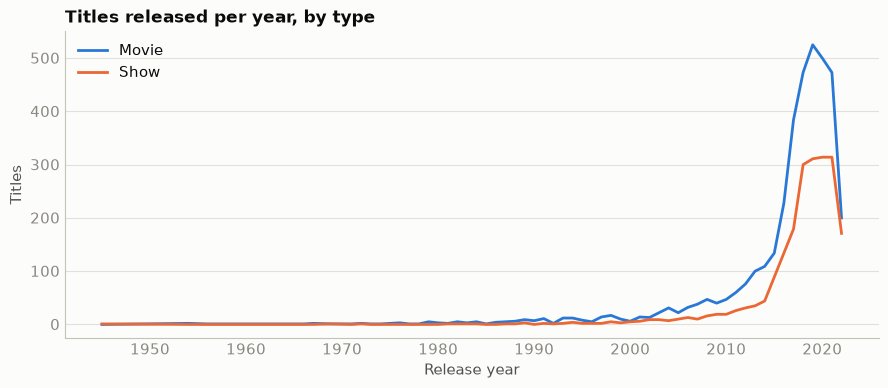

In [2]:
# sql/01_titles_by_year_and_type.sql
df1 = run_sql("01_titles_by_year_and_type.sql")
pivot1 = df1.pivot(index="release_year", columns="type", values="title_count").fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pivot1.index, pivot1["MOVIE"], color=BLUE, linewidth=2, label="Movie")
ax.plot(pivot1.index, pivot1["SHOW"], color=ORANGE, linewidth=2, label="Show")
style_axes(ax)
ax.set_title("Titles released per year, by type")
ax.set_xlabel("Release year")
ax.set_ylabel("Titles")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_titles_by_year_and_type.png", dpi=150, facecolor=SURFACE)
plt.show()

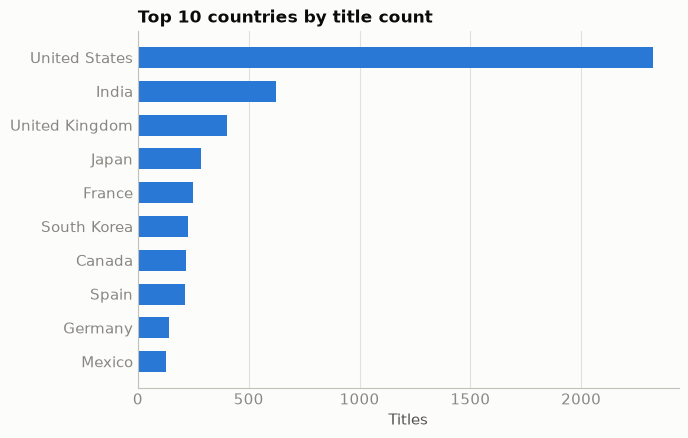

In [3]:
# sql/10_top_countries_by_title_count.sql
df10 = run_sql("10_top_countries_by_title_count.sql").sort_values("title_count")
df10["country_label"] = df10["country"].map(country_label)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(df10["country_label"], df10["title_count"], color=BLUE, height=0.62)
style_axes(ax, grid_axis="x")
ax.set_title("Top 10 countries by title count")
ax.set_xlabel("Titles")
plt.tight_layout()
plt.savefig(OUT_DIR / "10_top_countries_by_title_count.png", dpi=150, facecolor=SURFACE)
plt.show()

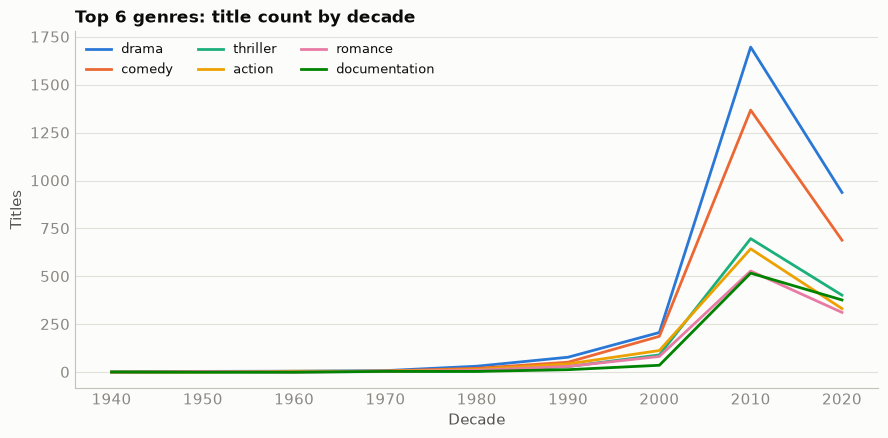

In [4]:
# sql/09_genre_trends_by_decade.sql
df9 = run_sql("09_genre_trends_by_decade.sql")
top6_genres = (
    df9.groupby("genre")["title_count"].sum().sort_values(ascending=False).head(6).index.tolist()
)
pivot9 = (
    df9[df9["genre"].isin(top6_genres)]
    .pivot(index="decade", columns="genre", values="title_count")
    .fillna(0)
    .reindex(columns=top6_genres)
)
colors9 = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN]

fig, ax = plt.subplots(figsize=(9, 4.5))
for genre, color in zip(top6_genres, colors9):
    ax.plot(pivot9.index, pivot9[genre], color=color, linewidth=2, label=genre)
style_axes(ax)
ax.set_title("Top 6 genres: title count by decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Titles")
ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "09_genre_trends_by_decade.png", dpi=150, facecolor=SURFACE)
plt.show()

## Ratings

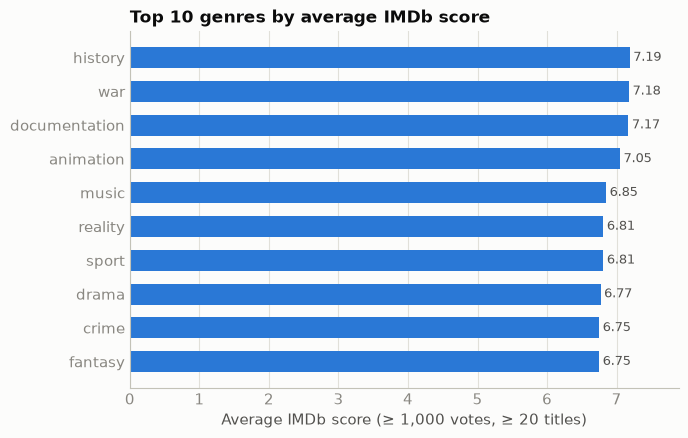

In [5]:
# sql/02_top_genres_by_rating.sql
df2 = run_sql("02_top_genres_by_rating.sql").sort_values("avg_imdb_score")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(df2["genre"], df2["avg_imdb_score"], color=BLUE, height=0.62)
for bar, val in zip(bars, df2["avg_imdb_score"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9, color=INK_SOFT)
style_axes(ax, grid_axis="x")
ax.set_xlim(0, df2["avg_imdb_score"].max() + 0.7)
ax.set_title("Top 10 genres by average IMDb score")
ax.set_xlabel("Average IMDb score (\u2265 1,000 votes, \u2265 20 titles)")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_top_genres_by_rating.png", dpi=150, facecolor=SURFACE)
plt.show()

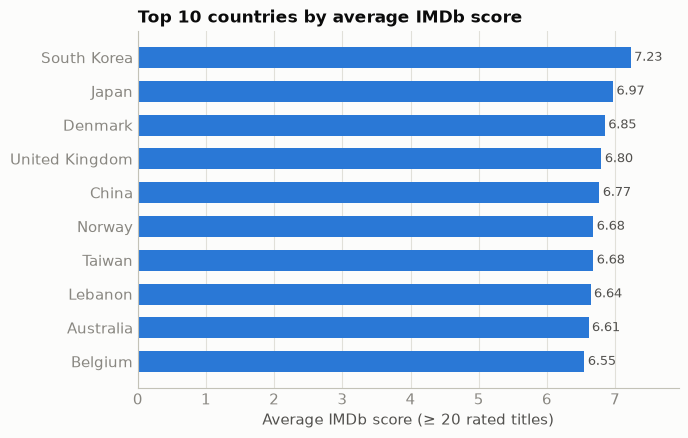

In [6]:
# sql/04_top_countries_by_rating.sql
df4 = run_sql("04_top_countries_by_rating.sql").sort_values("avg_imdb_score")
df4["country_label"] = df4["country"].map(country_label)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(df4["country_label"], df4["avg_imdb_score"], color=BLUE, height=0.62)
for bar, val in zip(bars, df4["avg_imdb_score"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9, color=INK_SOFT)
style_axes(ax, grid_axis="x")
ax.set_xlim(0, df4["avg_imdb_score"].max() + 0.7)
ax.set_title("Top 10 countries by average IMDb score")
ax.set_xlabel("Average IMDb score (\u2265 20 rated titles)")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_top_countries_by_rating.png", dpi=150, facecolor=SURFACE)
plt.show()

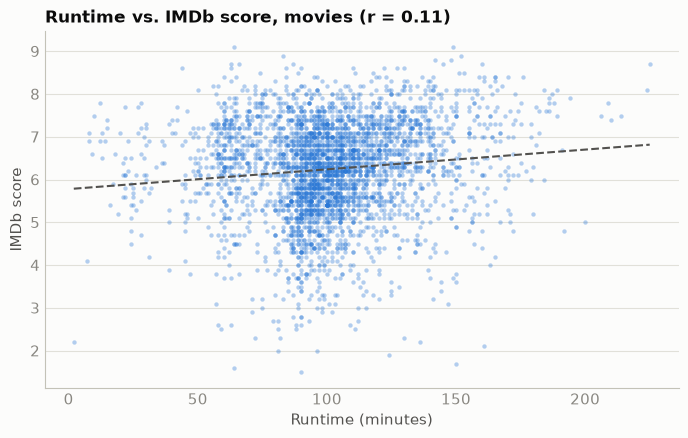

In [7]:
# sql/05_runtime_vs_rating_correlation.sql — the file returns the correlation coefficient
# itself; the scatter needs the underlying rows, pulled with the identical filter the
# query documents (type = MOVIE, has a score, runtime not flagged missing).
corr_result = run_sql("05_runtime_vs_rating_correlation.sql").iloc[0]
with sqlite3.connect(DB_PATH) as conn:
    df5 = pd.read_sql(
        """
        SELECT runtime, imdb_score
        FROM titles_cleaned
        WHERE type = 'MOVIE' AND imdb_score IS NOT NULL AND runtime_is_missing = 0
        """,
        conn,
    )

trend_coefs = np.polyfit(df5["runtime"], df5["imdb_score"], 1)
trend_x = np.linspace(df5["runtime"].min(), df5["runtime"].max(), 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df5["runtime"], df5["imdb_score"], s=10, alpha=0.35, color=BLUE, linewidths=0)
ax.plot(trend_x, np.polyval(trend_coefs, trend_x), color=INK_SOFT, linewidth=1.5, linestyle="--")
style_axes(ax)
ax.set_title(f"Runtime vs. IMDb score, movies (r = {corr_result['pearson_r']:.2f})")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("IMDb score")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_runtime_vs_rating_correlation.png", dpi=150, facecolor=SURFACE)
plt.show()

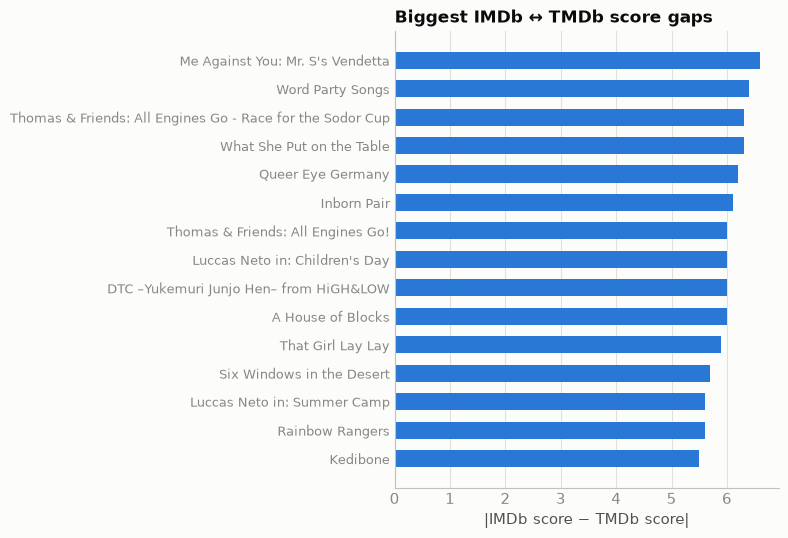

In [8]:
# sql/06_imdb_tmdb_score_gap.sql
df6 = run_sql("06_imdb_tmdb_score_gap.sql").sort_values("score_gap")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(df6["title"], df6["score_gap"], color=BLUE, height=0.6)
style_axes(ax, grid_axis="x")
ax.tick_params(axis="y", labelsize=9)
ax.set_title("Biggest IMDb \u2194 TMDb score gaps")
ax.set_xlabel("|IMDb score \u2212 TMDb score|")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_imdb_tmdb_score_gap.png", dpi=150, facecolor=SURFACE)
plt.show()

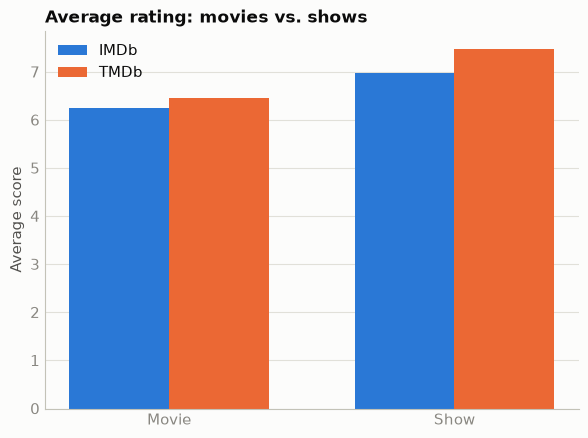

In [9]:
# sql/08_movie_vs_show_avg_rating.sql
df8 = run_sql("08_movie_vs_show_avg_rating.sql")
x8 = np.arange(len(df8))
width8 = 0.35

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(x8 - width8 / 2, df8["avg_imdb_score"], width8, color=BLUE, label="IMDb")
ax.bar(x8 + width8 / 2, df8["avg_tmdb_score"], width8, color=ORANGE, label="TMDb")
ax.set_xticks(x8)
ax.set_xticklabels(df8["type"].str.title())
style_axes(ax)
ax.set_title("Average rating: movies vs. shows")
ax.set_ylabel("Average score")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "08_movie_vs_show_avg_rating.png", dpi=150, facecolor=SURFACE)
plt.show()

## People

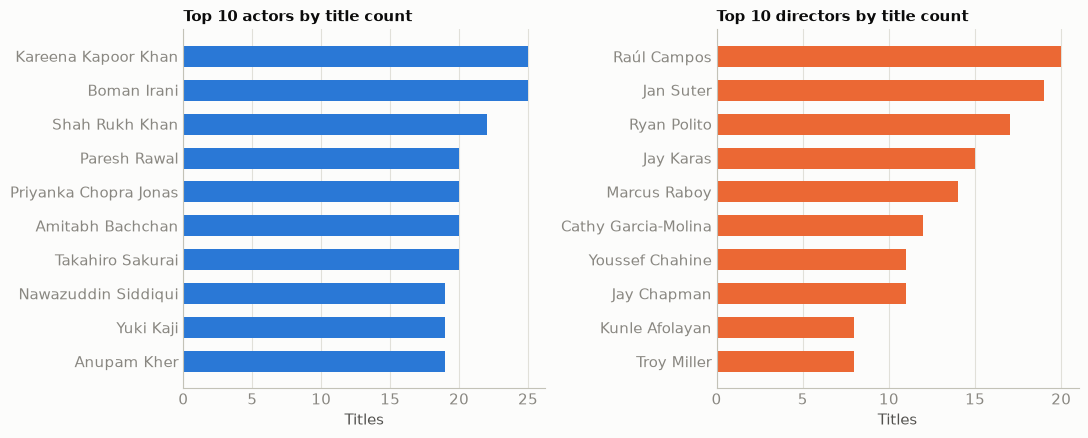

In [10]:
# sql/03_top_prolific_actors_directors.sql
df3 = run_sql("03_top_prolific_actors_directors.sql")
actors3 = df3[df3["role"] == "ACTOR"].sort_values("title_count")
directors3 = df3[df3["role"] == "DIRECTOR"].sort_values("title_count")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(actors3["name"], actors3["title_count"], color=BLUE, height=0.62)
axes[1].barh(directors3["name"], directors3["title_count"], color=ORANGE, height=0.62)
for ax, title in zip(axes, ["Top 10 actors by title count", "Top 10 directors by title count"]):
    style_axes(ax, grid_axis="x")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Titles")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_top_prolific_actors_directors.png", dpi=150, facecolor=SURFACE)
plt.show()

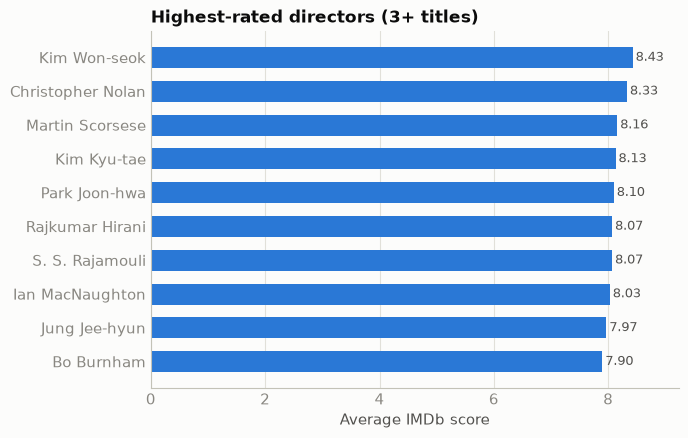

In [11]:
# sql/07_top_directors_min_3_titles.sql
df7 = run_sql("07_top_directors_min_3_titles.sql").sort_values("avg_imdb_score")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(df7["name"], df7["avg_imdb_score"], color=BLUE, height=0.62)
for bar, val in zip(bars, df7["avg_imdb_score"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9, color=INK_SOFT)
style_axes(ax, grid_axis="x")
ax.set_xlim(0, df7["avg_imdb_score"].max() + 0.8)
ax.set_title("Highest-rated directors (3+ titles)")
ax.set_xlabel("Average IMDb score")
plt.tight_layout()
plt.savefig(OUT_DIR / "07_top_directors_min_3_titles.png", dpi=150, facecolor=SURFACE)
plt.show()

## Composite dashboard

Six headline panels — one image, `dashboard/dashboard.png`, linked from the README.

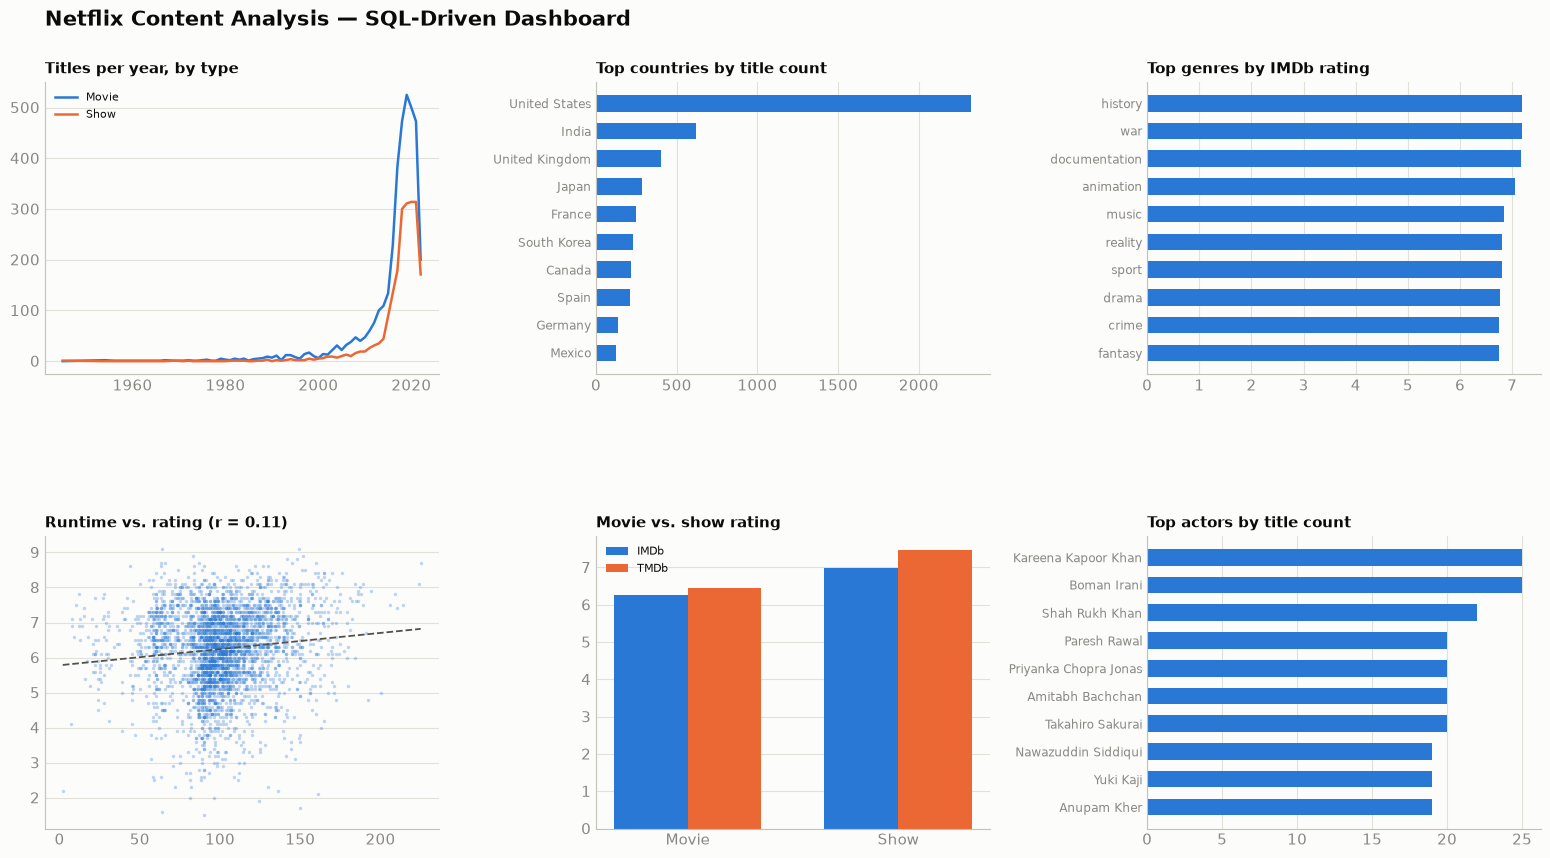

In [12]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, hspace=0.55, wspace=0.4, top=0.90, bottom=0.07, left=0.045, right=0.98)

ax = fig.add_subplot(gs[0, 0])
ax.plot(pivot1.index, pivot1["MOVIE"], color=BLUE, linewidth=1.8, label="Movie")
ax.plot(pivot1.index, pivot1["SHOW"], color=ORANGE, linewidth=1.8, label="Show")
style_axes(ax)
ax.set_title("Titles per year, by type", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax = fig.add_subplot(gs[0, 1])
ax.barh(df10["country_label"], df10["title_count"], color=BLUE, height=0.6)
style_axes(ax, grid_axis="x")
ax.set_title("Top countries by title count", fontsize=11)
ax.tick_params(axis="y", labelsize=8.5)

ax = fig.add_subplot(gs[0, 2])
ax.barh(df2["genre"], df2["avg_imdb_score"], color=BLUE, height=0.6)
style_axes(ax, grid_axis="x")
ax.set_title("Top genres by IMDb rating", fontsize=11)
ax.tick_params(axis="y", labelsize=8.5)

ax = fig.add_subplot(gs[1, 0])
ax.scatter(df5["runtime"], df5["imdb_score"], s=6, alpha=0.3, color=BLUE, linewidths=0)
ax.plot(trend_x, np.polyval(trend_coefs, trend_x), color=INK_SOFT, linewidth=1.3, linestyle="--")
style_axes(ax)
ax.set_title(f"Runtime vs. rating (r = {corr_result['pearson_r']:.2f})", fontsize=11)

ax = fig.add_subplot(gs[1, 1])
ax.bar(x8 - width8 / 2, df8["avg_imdb_score"], width8, color=BLUE, label="IMDb")
ax.bar(x8 + width8 / 2, df8["avg_tmdb_score"], width8, color=ORANGE, label="TMDb")
ax.set_xticks(x8)
ax.set_xticklabels(df8["type"].str.title())
style_axes(ax)
ax.set_title("Movie vs. show rating", fontsize=11)
ax.legend(frameon=False, fontsize=8)

ax = fig.add_subplot(gs[1, 2])
ax.barh(actors3["name"], actors3["title_count"], color=BLUE, height=0.6)
style_axes(ax, grid_axis="x")
ax.set_title("Top actors by title count", fontsize=11)
ax.tick_params(axis="y", labelsize=8.5)

fig.suptitle("Netflix Content Analysis \u2014 SQL-Driven Dashboard", fontsize=15, fontweight="bold", x=0.045, ha="left", color=INK)
plt.savefig(OUT_DIR / "dashboard.png", dpi=150, facecolor=SURFACE)
plt.show()